In [65]:
from google.colab import drive
import gzip
import random
import networkx as nx
from collections import deque
import matplotlib.pyplot as plt

drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab Notebooks/AM

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/AM


In [51]:
# all_nodes = set()
# all_edges = []

# with gzip.open('web-Google.txt.gz', 'rt') as f:
#   for line in f:
#     if line.startswith('#'):
#       continue
#     u, v = map(int, line.split())
#     all_nodes.add(u)
#     all_nodes.add(v)
#     all_edges.append((u, v))

# sample_nodes = set(random.sample(list(all_nodes), 300))

# sample_edges = [(u, v) for u, v in all_edges if u in sample_nodes and v in sample_nodes]

The commented code above, on its own, is practically (usually) useless since it uses the above sampling method on a relatively big dataset which won't reallz work considering how small the wanted sample (200-300 nodes) is.

In [52]:
adj = {}

with gzip.open('web-Google.txt.gz', 'rt') as f:
  for line in f:
    if line.startswith('#'):
      continue
    u, v = map(int, line.split())
    adj.setdefault(u, []).append(v)
    adj.setdefault(v, []) # ensure node exists

start = random.choice(list(adj.keys()))
visited = set([start])
queue = deque([start])

while queue and len(visited) < 300:
  node = queue.popleft()
  for neighbor in adj.get(node, []):
    if neighbor not in visited:
      visited.add(neighbor)
      queue.append(neighbor)
    if len(visited) >= 300:
      break

# keep edges inside sampled nodes
sample_edges = [(u, v) for u in visited for v in adj.get(u, []) if v in visited]

In [55]:
G = nx.DiGraph()
G.add_nodes_from(visited)
G.add_edges_from(sample_edges)

print(f"Nodes: {nx.number_of_nodes(G)}, Vertices: {nx.number_of_edges(G)}")

Nodes: 300, Vertices: 2751


In [56]:
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print("Some nodes in-degree vs out-degree:")
for node in list(G.nodes())[:10]:
  print(f"Node {node}: in-degree={in_degrees[node]}, out-degree={out_degrees[node]}")

avg_in = sum(in_degrees.values()) / len(in_degrees)
avg_out = sum(out_degrees.values()) / len(out_degrees)
print(f"\nAverage in-degree: {avg_in:.2f}, Average out-degree: {avg_out:.2f}")

Some nodes in-degree vs out-degree:
Node 285698: in-degree=3, out-degree=10
Node 126978: in-degree=5, out-degree=1
Node 81410: in-degree=3, out-degree=0
Node 546821: in-degree=2, out-degree=0
Node 412858: in-degree=3, out-degree=5
Node 297993: in-degree=6, out-degree=13
Node 642059: in-degree=15, out-degree=23
Node 15374: in-degree=5, out-degree=11
Node 548308: in-degree=2, out-degree=11
Node 539669: in-degree=30, out-degree=18

Average in-degree: 9.17, Average out-degree: 9.17


In-links and out-links degrees are quite varied on the web as it could be expected (and viewed from the above in/out degree results). For example, while a site like Facebook has many in-links (due to popularity) there, a more obscure collection of blogs might have many out-links, but not many in-links.

Average in-degrees and out-degrees are the same which makes sense for a directed graph.

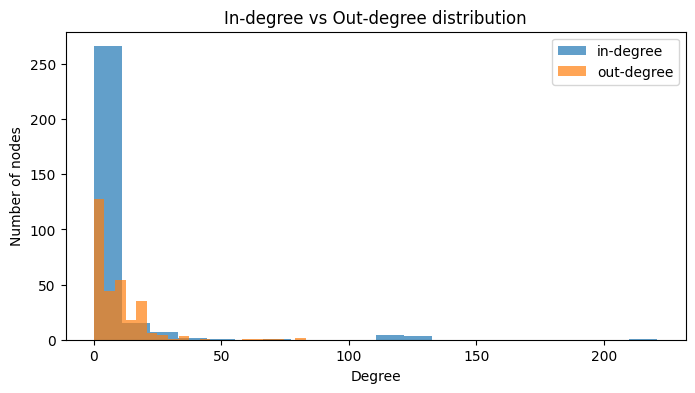

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(list(in_degrees.values()), bins=20, alpha=0.7, label='in-degree')
plt.hist(list(out_degrees.values()), bins=20, alpha=0.7, label='out-degree')
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.legend()
plt.title("In-degree vs Out-degree distribution")
plt.show()

The nodes (websites) have a relatively wide range of degrees ("in" and "out" hyperlinks), but nonetheless, most nodes exhibit a much lower degree of connectivity.

In [60]:
weak_cc = list(nx.weakly_connected_components(G))
print(f"Number of weakly connected components: {len(weak_cc)}")

largest_weak = max(weak_cc, key=len)
print(f"Largest weakly connected component size: {len(largest_weak)}")

Number of weakly connected components: 1
Largest weakly connected component size: 300


All of the sampled nodes make one big weakly connected component (graph, or rather subgraph)

In [62]:
strong_cc = list(nx.strongly_connected_components(G))
print(f"Number of strongly connected components: {len(strong_cc)}")

largest_strong = max(strong_cc, key=len)
print(f"Largest strongly connected component size: {len(largest_strong)}")

Number of strongly connected components: 59
Largest strongly connected component size: 228


There are more SCCs than WCCs which is to be expected.

In [77]:
H = G.subgraph(largest_strong).copy()

nodes = list(H.nodes())
u, v = random.sample(nodes, 2)

shortest_path = nx.shortest_path(H, source=u, target=v)
print(f"Shortest path from {u} to {v}: {shortest_path}")

print(f"Number of edges in this path: {len(shortest_path)-1}")

Shortest path from 14123 to 153176: [14123, 359871, 10676, 153176]
Number of edges in this path: 3


The above code shows the shortest path between 2 random nodes.

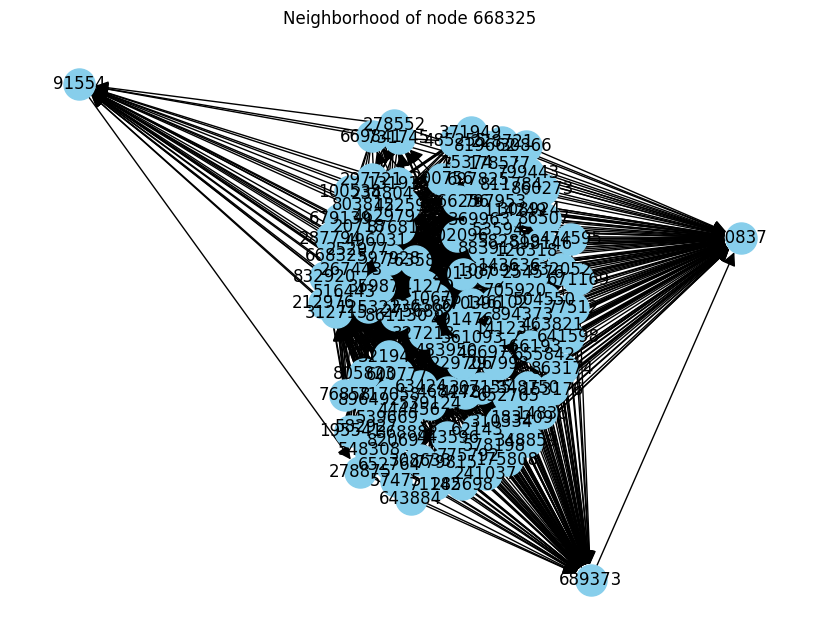

In [67]:
center_node = random.choice(list(G.nodes()))

neighbors = set(G.successors(center_node)) # nodes it points to
neighbors.update(G.predecessors(center_node)) # nodes pointing to it

neighbors.add(center_node)

subG = G.subgraph(neighbors).copy()

plt.figure(figsize=(8,6))

pos = nx.spring_layout(subG) # automatic layout
nx.draw(subG, pos, with_labels=True, node_size=500, node_color='skyblue', arrowsize=20)

plt.title(f"Neighborhood of node {center_node}")
plt.show()

The above directed graph shows just a small sample of an interconnected network that is, even now, quite difficult to decipher due to the vast number of vertices and edges.